[*********************100%***********************]  1 of 1 completed


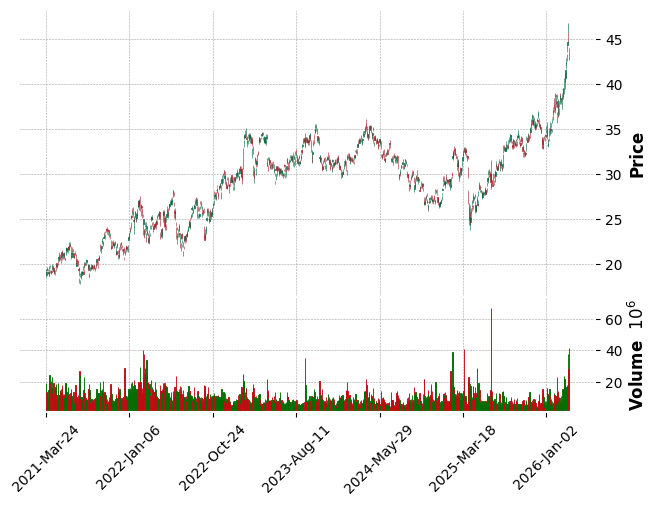

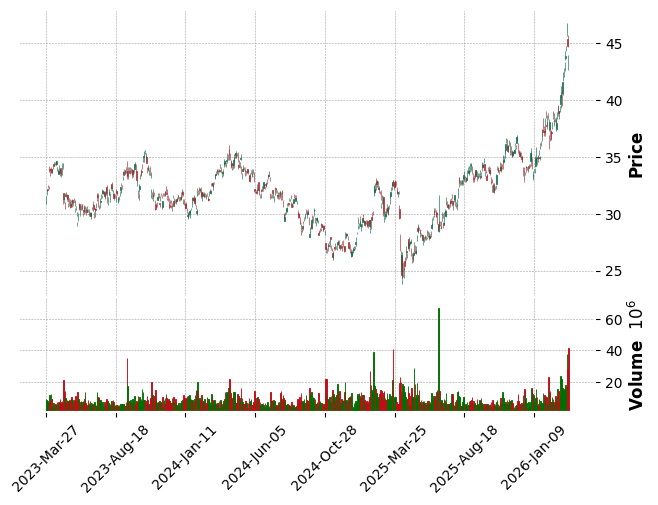

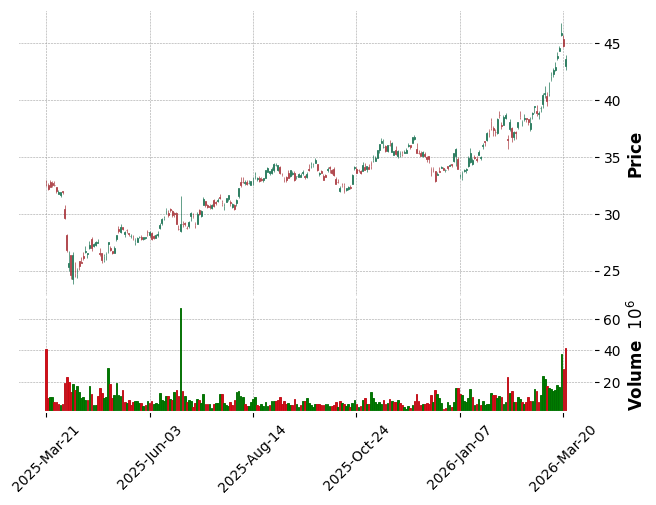

In [1]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
Fun = Fundamentals(name, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-252:], type='candle', style='charles',volume=True)

In [2]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


43.57


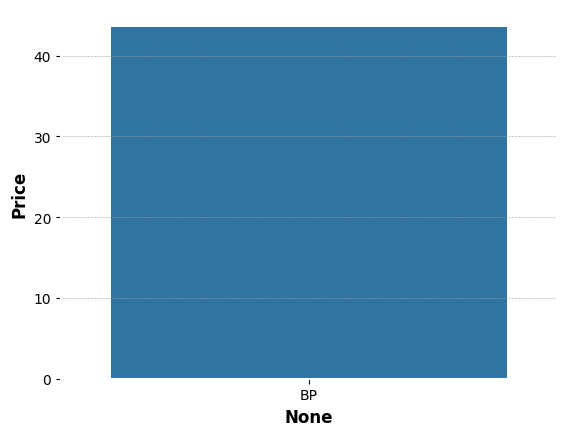

In [3]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [4]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [5]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [6]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

Bearish (Net Sell): -338,632 shares


In [7]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-23 02:30:20
Dividend Harvesting Portfolio Week 264: $26,400 Allocated, $2,869 In Projected Dividends
Dividend Harvesting Portfolio update: $2,869 forward income and 33.1% ROI.
https://finnhub.io/api/news?id=b219ff214a176299abd171385f79377111add06f92752d04f1c73164f286b1bc

2026-03-23 02:13:55
Shares of oil-related companies are trading lower after President Trump announced in a Truth Social post the suspension of U.S. strikes on Iranian power generation and energy infrastructure for five days, subject to the outcome of ongoing discussions.

https://finnhub.io/api/news?id=6af06ccc3919bf63c2a484b2bbf9d2f9ab2413c467a9800b8812ac89aaf4e7d4

2026-03-20 18:04:27
HSBC Upgrades BP p.l.c. - Depositary Receipt (BP)

https://finnhub.io/api/news?id=eee382bce9a7cb3a3b72f799f04591e8c84c31086400019362ab734174732148

2026-03-20 03:01:59
This Rubrik Analyst Begins Coverage On A Bullish Note; Here Are Top 4 Initiations For Friday
Wall Street analysts changed ratings on top stocks. For insights on 

Average Weighted EPS: 0.0782
Lower Standard Deviation: -0.16534591085533723
Upper Standard Deviation: 0.3217459108553372
Total Debt/Total Equity: 1.3671


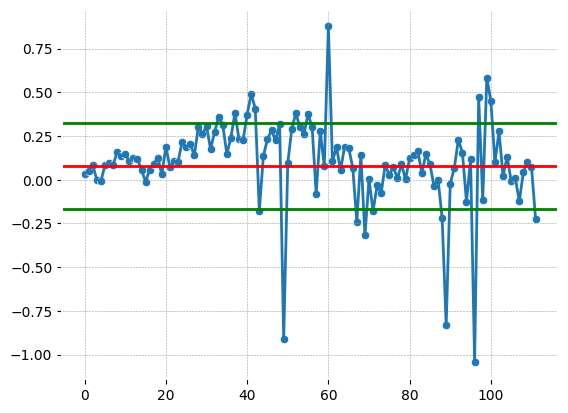

In [8]:
inflect = Fun.get_inflections()

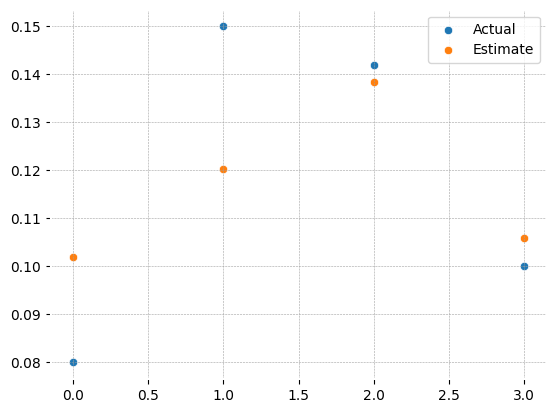

In [9]:
surprise = Fun.eps_surprise()

2025-12-31   189335000000.00
2024-12-31   189185000000.00
2023-12-31   210130000000.00
2022-12-31   241392000000.00
2021-12-31               NaN
Name: Total Revenue, dtype: float64
Revenue: [1.89335e+11 1.89185e+11 2.10130e+11 2.41392e+11         nan]


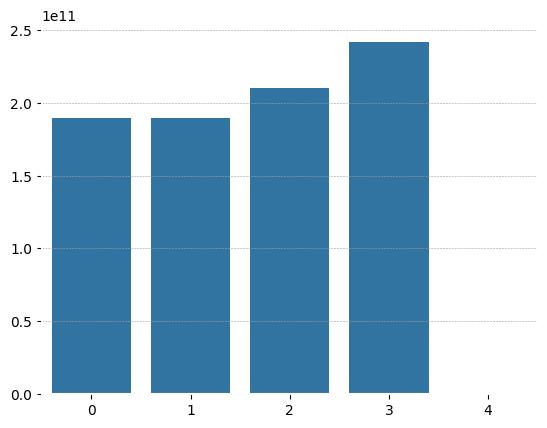

In [13]:
revenue = Fun.revenue_growth()